***Partie 2 du projet : Utilisation d'agents***

Afin d'aider les architectes à réaliser un bâtiment plus économique en énergie (pour le chauffage et la climatisation), un ou plusieurs agents proposent des optimisations. Ces agents utiliseront un des modèles créé dans la partie 1 du projet.

**Plan de cette partie :**
- Création d'un modèle "aléatoire" de bâtiment très simple (un cube) et des caractéristiques associées
- Création d'un agent utilisant l'algorithme de Q-Network
- Création d'un agent utlisant l'algoritme de Deep Q-Network
- Utilisation de 2 agents utilisant le Deep Q-Network (un pour le chauffage et un pour la climatisation). Ces agents pourront ou non être coordonnés.
- Utilisation d'une hiérarchie d'agents (un manager, un agent pour le chauffage et un pour la climatisation)
- Synthèse et analyse des différentes approches

**1. Installation et import des librairies**

In [63]:
!pip install ipywidgets
!pip install joblib
!pip install scikit-learn
!pip install xgboost
!pip install torch
!pip install pandas

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import random
import numpy as np
from collections import defaultdict
import ipywidgets as widgets
from IPython.display import display, clear_output
import joblib
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import pandas as pd

**2. Création d'un batiment "cubique" de manière aléatoire**

- La surface, le ratio longueur-largeur, la hauteur, l'orientation et la surface vitrée sont initialisés de manière aléatoire
- La largeur, la profondeur, la surface des murs, la compacité relative sont calculées à partir de ces valeurs

- Les coordonnées des sommets sont ensuite estimés afin de pouvoir faire un affichage 3D du cube et des surfaces vitrées


In [3]:
def creer_batiment_3D():

    # Surface du bâtiment avec une valeur de 318 m² + ou - 30%
    surface = int(318 * random.uniform(0.7, 1.3))

    # Ratio largeur/profondeur aléatoire (0.5 = profond, 2.0 = large)
    ratio = random.uniform(0.5, 2.0)
    largeur = int((surface * ratio) ** 0.5)
    profondeur = max(1, int(surface / max(largeur, 1)))

    # Hauteur aléatoire
    hauteur = max(1, int(5.25 * random.uniform(0.5, 3)))
   
    # Calcul de f_wall_area
    f_wall_area = 2 * (largeur + profondeur) * hauteur

    # Calcul de la compacité relative
    volume = largeur * profondeur * hauteur
    surface_enveloppe = 2 * (largeur * profondeur + largeur * hauteur + profondeur * hauteur)
    # Calcul pour un cube de même volume
    surface_cube = 6 * (volume ** (2/3))
    f_relative_compactness = (volume / surface_enveloppe) / (volume / surface_cube)

    # Calcul de glazing_area
    f_glazing_area = random.uniform(0, 0.4)  # Surface vitrée aléatoire entre 0% et 40%
  
    # Definition des 8 sommets du cube (les 4 premiers sont ceux de la base)
    x = [0, largeur, largeur, 0, 0, largeur, largeur, 0]
    y = [0, 0, profondeur, profondeur, 0, 0, profondeur, profondeur]
    z = [0, 0, 0, 0, hauteur, hauteur, hauteur, hauteur]
    
    # Rotation aleatoire
    f_orientation = random.randint(2,5)
    angle = (f_orientation-2)* np.pi/2
    cos_a, sin_a = np.cos(angle), np.sin(angle)
    x_rot = [cos_a * xi - sin_a * yi for xi, yi in zip(x, y)]
    y_rot = [sin_a * xi + cos_a * yi for xi, yi in zip(x, y)]
    
    # Définition des coordonnées
    verts1 = [
        [ [x_rot[0],y_rot[0],z[0]], [x_rot[1],y_rot[1],z[1]], [x_rot[2],y_rot[2],z[2]], [x_rot[3],y_rot[3],z[3]] ], # bas
        [ [x_rot[4],y_rot[4],z[4]], [x_rot[5],y_rot[5],z[5]], [x_rot[6],y_rot[6],z[6]], [x_rot[7],y_rot[7],z[7]] ], # haut
        [ [x_rot[0],y_rot[0],z[0]], [x_rot[1],y_rot[1],z[1]], [x_rot[5],y_rot[5],z[5]], [x_rot[4],y_rot[4],z[4]] ], # côté 1 (avant)
        [ [x_rot[2],y_rot[2],z[2]], [x_rot[3],y_rot[3],z[3]], [x_rot[7],y_rot[7],z[7]], [x_rot[6],y_rot[6],z[6]] ], # côté 2 (arrière)
        [ [x_rot[1],y_rot[1],z[1]], [x_rot[2],y_rot[2],z[2]], [x_rot[6],y_rot[6],z[6]], [x_rot[5],y_rot[5],z[5]] ], # côté 3 (droite)
        [ [x_rot[4],y_rot[4],z[4]], [x_rot[7],y_rot[7],z[7]], [x_rot[3],y_rot[3],z[3]], [x_rot[0],y_rot[0],z[0]] ], # côté 4 (gauche)
    ]
   
    # Création de la figure 3D
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_title("Bâtiment", fontsize=30, fontweight='bold')
    
    # Cube
    ax.add_collection3d(Poly3DCollection(verts1, facecolors='lightgrey', linewidths=1, edgecolors='black', alpha=0.7))

    # Ajout de la surface vitrée sur chaque face
    faces_indices = [
        [0, 1, 5, 4],  # avant
        [2, 3, 7, 6],  # arrière
        [1, 2, 6, 5],  # droite
        [4, 7, 3, 0],  # gauche
    ]
    
    # Calcul surface totale des 4 faces verticales
    face_surfaces = []
    for idxs in faces_indices:
        p0, p1, p2, p3 = idxs
        largeur_face = np.linalg.norm([x_rot[p1] - x_rot[p0], y_rot[p1] - y_rot[p0]])
        hauteur_face = np.linalg.norm([z[p2] - z[p1]])
        face_surfaces.append(largeur_face * hauteur)
    
    # Surface vitrée par face
    surface_vitree_par_face = f_glazing_area * f_wall_area / 4

    for idxs, surf_face in zip(faces_indices, face_surfaces):
        p0, p1, p2, p3 = idxs
        x0, y0, z0 = x_rot[p0], y_rot[p0], z[p0]
        x1, y1, z1 = x_rot[p1], y_rot[p1], z[p1]
        largeur_face = np.linalg.norm([x1 - x0, y1 - y0])

        # Centrage de la fenêtre sur la face
        glazing_height = surface_vitree_par_face / max(largeur_face, 1)
        glazing_width = surface_vitree_par_face / max(glazing_height, 1)
    
        # Si la fenêtre dépasse la face, on limite à la taille de la face
        if glazing_height > hauteur:
            glazing_height = hauteur
            glazing_width = surface_vitree_par_face / hauteur
        if glazing_width > largeur_face:
            glazing_width = largeur_face
            glazing_height = surface_vitree_par_face / largeur_face

        dx = (x1 - x0) / largeur_face
        dy = (y1 - y0) / largeur_face
        base_x = x0 + (largeur_face - glazing_width) / 2 * dx
        base_y = y0 + (largeur_face - glazing_width) / 2 * dy


        z_base = (hauteur - glazing_height) / 2
        glazing_verts = [
            [base_x, base_y, z_base ],
            [base_x + glazing_width * dx, base_y + glazing_width * dy, z_base],
            [base_x + glazing_width * dx, base_y + glazing_width * dy, z_base + glazing_height],
            [base_x, base_y, z_base + glazing_height]
        ]

        ax.add_collection3d(Poly3DCollection([glazing_verts], facecolors='gold', linewidths=2, edgecolors='navy', alpha=0.9))
    
    # Affichage des axes
    ax.set_xlabel('Largeur (m)', fontsize=14, labelpad=20)
    ax.set_ylabel('Profondeur (m)', fontsize=14, labelpad=20)
    ax.set_zlabel('Hauteur (m)', fontsize=14, labelpad=20, rotation=90)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.tick_params(axis='z', which='major', labelsize=12, pad=10)
    ax.view_init(elev=20, azim=30)

    ax.set_xlim(min(x_rot), max(x_rot))
    ax.set_ylim(min(y_rot), max(y_rot))
    ax.set_zlim(0, hauteur)

    plt.figtext(
    0.02, 0.02,
    f"Hauteur: {hauteur:.2f} m\n"
    f"Surface totale: {surface:.2f} m\n"
    f"f_relative_compactnes: {f_relative_compactness:.2f}\n"
    f"f_wall_area: {f_wall_area:.2f} m\n"
    f"f_glazing_area: {f_glazing_area:.2f}\n"
    f"f_orientation: {f_orientation}\n",
    fontsize=10, ha='left', va='bottom', bbox=dict(facecolor='white', alpha=0.7)
)
    # Garder la même échelle sur tous les axes
    max_range = max(
        max(x_rot) - min(x_rot),
        max(y_rot) - min(y_rot),
        hauteur
    ) / 2.0

    mid_x = (max(x_rot) + min(x_rot)) / 2.0
    mid_y = (max(y_rot) + min(y_rot)) / 2.0
    mid_z = hauteur / 2.0

    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)

    plt.show()
    return {
        'f_glazing_area': f_glazing_area,
        'f_orientation': f_orientation,
        'f_overall_height': hauteur,
        'f_relative_compactness': f_relative_compactness,
        'f_wall_area': f_wall_area
    }

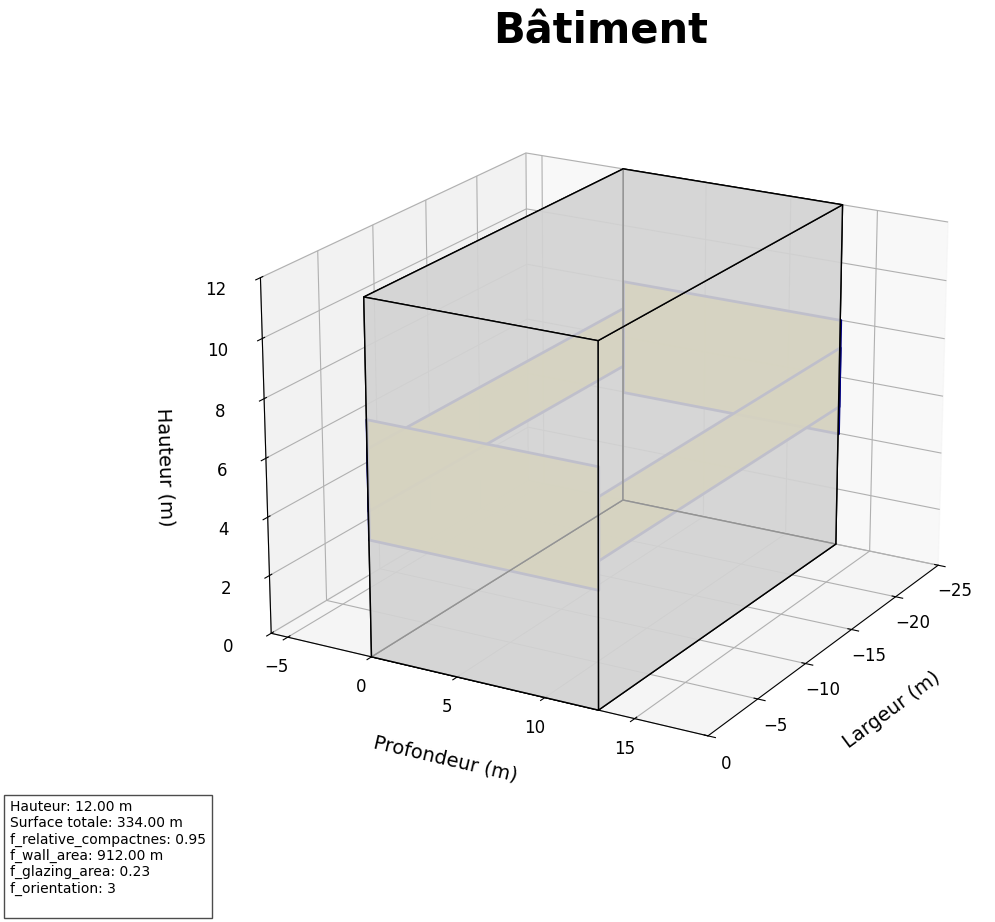

{'f_glazing_area': 0.2289204545812004, 'f_orientation': 3, 'f_overall_height': 12, 'f_relative_compactness': 0.9517289766709167, 'f_wall_area': 912}


In [4]:
variables=creer_batiment_3D()
print(variables)

**3. Algorithme Q-learning**

Le Q-learning est un algorithme d'apprentissage par renforcement. 

Le principe est le suivant : à chaque état, l'agent peut choisir entre plusieurs actions. Il cherchera à maximiser la somme des récompenses reçues à long terme.

L'objectif de l'algorithme est d'apprendre une fonction Q. Cette fonction Q(s,a) associe une valeur estimant la récompense totale attendue si l'agent dans l'état s prend l'action a et suit la meilleur politique possible.

A chaque étape, la valeur Q est mise à jour avec la règle de Bellman

Note 1 : Dans notre cas, commme nous cherchons à minimiser l'énergie consommée, la fonction de récompense sera donc l'opposé de l'estimation de la consommation énergétique prédite par le modèle utilisé.

Note 2 : on donne la possibilité à l'architecte de bloquer un des paramètres.

**3.1 Chargement du modèle et définition des paramètres**
- Définition des paramètres, des limites et des steps pour chacun des paramètres
- Chargement des modèles de prédiction de la consommation 
- Fonction de préparation des données avant appel du modèle (modification des types)

In [5]:
#définition de la liste de paramètres du bâtiment
param_names = ['f_relative_compactness', 'f_wall_area', 'f_overall_height','f_glazing_area', 'f_orientation']

#valeurs limites des paramètres
param_bounds = {
    'f_relative_compactness': (0.5, 1.0),
    'f_wall_area': (100, 3000),
    'f_overall_height': (2.625, 15.75),
    'f_glazing_area': (0, 0.4),
    'f_orientation': (2, 5)
}

# Taille des steps
param_steps = {
    'f_relative_compactness': 0.05,
    'f_wall_area': 10,
    'f_overall_height': 1,
    'f_glazing_area':0.05,
    'f_orientation': 1
}

#Chemin de stockage des modèles
model_path_l_cooling_load = "saved_models/lgbmregressor_l_cooling_load.joblib"
model_path_l_heating_load = "saved_models/lgbmregressor_l_heating_load.joblib"

#Chargement de modèles réalisés dans la partie 1
model_clim = joblib.load(model_path_l_cooling_load)
model_chauffage = joblib.load(model_path_l_heating_load)

#Fonction de préparation des données en amont de l'usage des modèles
def prepare_data(df: pd.DataFrame):
    for col in df.columns:
        if col == 'f_orientation':
            # conversion en category du paramètre orientation
            df[col] = df[col].astype('category')
        else:
            # conversion en numérique des autres paramètres
            df[col] = pd.to_numeric(df[col], errors='raise')

    return df

**3.3 Fonction de récompenses**

Avec cet algorithme dans le cas d'un agent unique, il y a une seule fonction de récompense de manière standard. La fonction de récompense sera donc l'opposé de la somme des prédictions énergétique du chauffage et de la climatisation.

In [6]:
def reward_func(params: dict) -> float:
    """
    Construit un DataFrame à partir de `params`, applique les 
    mêmes transformations que lors de l’entraînement,
    puis prédit chauffage + clim et retourne la récompense = -(chauff + clim).
    """
    
    # On forme un DataFrame 1 ligne à partir du dictionnaire `params`
    df = pd.DataFrame([{
        'f_relative_compactness': params['f_relative_compactness'],
        'f_wall_area':           params['f_wall_area'],
        'f_overall_height':      params['f_overall_height'],
        'f_glazing_area':        params['f_glazing_area'],
        'f_orientation':         params['f_orientation']
    }])

    # On modifie les types des donnée
    X = prepare_data(df)

    # On prédit la consommation en chauffage et en climatisation
    chauffage = model_chauffage.predict(X)[0]
    clim      = model_clim.predict(X)[0]

    clim = np.exp(clim)
    chauffage = np.exp(chauffage)

    # On renvoie la récompense (opposé de la consommation estimée)
    return -(chauffage + clim)

**3.4 Définition de la classe QLearningAgent**

**Paramètres en entrée :** 
- param_names = liste des paramètres à optimiser
- param_bounds = listes des valeurs minimales et maximales pour chaque paramètre
- param_steps = pas d'évolution de chaque paramètre à chaque action
- alpha = taux d'apprentissage
- gamma (facteur de discount) = si gamma est proche de 0, l'agent ne s'intéresse qu'à la récompense immédiate, si gamma est proche de 1, il s'intéresse aux récompenses futures. Avec 0.9, il prend en compte les récompenses immédiates et futures.
- epsilon (comportement d'exploration de l'agent) = si epsilon égale 1, il fait des actions au hasard, si epsilon vaut 0, il prend toujours la valeur la plus importante dans la table q_table. Epsilon variera au cours de l'apprentissage.

**Fonction build_actions :**
L'agent peut prendre deux actions pour chacun des paramètres : augmenter ou diminuer d'un pas.

**Fonction discretize :**
Pour que la table q_table qui associe les couples (état, action) ne soit pas trop grande, on limite le nombre d'état en ne conservant que les valeurs entières.

**Fonction choose_action :**
L'action est choisie au hasard dans epsilon% des cas et dans les autres cas on prend l'action qui a la meilleure valeur de Q pour l'état actuel.

**Fonction update :**
Cette fonction met à jour la valeur de Q associée au couple (état, action). La valeur représente l'estimation de la récompense totale s'il fait cette action depuis cet état.
La fonction de mise à jour utilise la formule suivante : Q(s, a) ← Q(s, a) + alpha × [récompense immédiate + gamma × meilleure Q suivante − Q(s, a)]

**Fonction run_episode :**
À chaque étape :
-On choisit une action
-On applique l’action (on modifie le paramètre concerné)
-On calcule la récompense (par exemple, l’opposé de la consommation d’énergie)
-On met à jour la table Q
-On passe à l’état suivant
À la fin, on retourne les meilleurs paramètres trouvés et la récompense obtenue

In [7]:
class QLearningAgent:
    def __init__(self, param_names, param_bounds, param_steps, alpha=0.1, gamma=0.9, epsilon=0.2):
        self.param_names = param_names
        self.param_bounds = param_bounds
        self.param_steps = param_steps
        self.actions = self._build_actions()
        self.q_table = defaultdict(float)
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon

    # Définition des actions possibles pour chaque paramètre
    def _build_actions(self):
        actions = []
        for name in self.param_names:
            step = self.param_steps[name]
            actions.append((name, step))
            actions.append((name, -step))
        return actions
    
    # Discrétisation des paramètres
    def discretize(self, params):
        d = []
        for n in self.param_names:
            step = self.param_steps[n]
            #f_orientation ne prend que des valeurs entières, on orrondit pour la convertir en entier
            if n == 'f_orientation':
                d.append(int(round(params[n])))
            #pour les autres paramètres, on normalise (params[n] - min) / (step) puis on arrondit      
            else:
                d.append(int(round((params[n] - self.param_bounds[n][0]) / step)))
        return tuple(d)

    # Choix de l'action
    def choose_action(self, state):
        # Action choisie au hasard avec une probabilité epsilon
        if np.random.rand() < self.epsilon:
            return self.actions[np.random.randint(len(self.actions))]
        # Action choisie selon la valeur maximale de Q pour l'état donné et les actions possibles
        q_vals = [self.q_table[(state, a)] for a in self.actions]
        return self.actions[np.argmax(q_vals)]
    
    # Mise à jour de la valeur de Q
    def update(self, state, action, reward, next_state):
        # Recheche de la meilleure valeur de Q pour l'état suivant
        best_next = max([self.q_table[(next_state, a)] for a in self.actions])
        # Mise à jour de la valeur de Q pour l'état et l'action donnés
        self.q_table[(state, action)] += self.alpha * (reward + self.gamma * best_next - self.q_table[(state, action)])

    # Exécution d'un épisode de l'agent
    def run_episode(self, initial_params, reward_func, n_steps=20):
        params = initial_params.copy()
        state = self.discretize(params)
        #Répétition du processus d'apprentissage n_steps fois
        for _ in range(n_steps):
            #Sélection de l'action (paramètre et variation)
            action = self.choose_action(state)
            param, delta = action
            if param == 'f_orientation':
                # Cyclage entre {2, 3, 4, 5}
                new_ori = params['f_orientation'] + delta
                if new_ori < self.param_bounds['f_orientation'][0]:
                    new_ori = self.param_bounds['f_orientation'][1]
                elif new_ori > self.param_bounds['f_orientation'][1]:
                    new_ori = self.param_bounds['f_orientation'][0]
                params['f_orientation'] = int(new_ori)
            else:
                # Mise à jour du paramètre en respectant les bornes
                params[param] = np.clip(params[param] + delta, *self.param_bounds[param])
            next_state = self.discretize(params)
            # calcul de la récompense dans l'état suivant
            reward = reward_func(params)
            # Mise à jour de la valeur de Q
            self.update(state, action, reward, next_state)
            state = next_state
        return params, reward_func(params)

**3.5 Exécution :**

Lors de l'exécution, on peut saisir un paramètre à ne pas optimiser (par défaut tous les paramètres sont utilisés)

L'agent est ensuite exécuté pour un nombre défini d'épisodes (2OO).

Pour chaque épisode, la valeur epsilon est diminuée et les paramètres correspondant au meilleur score sont conservés.

In [8]:
def run_optim(param_to_fix=''):
    clear_output(wait=True)
    print("⚡ Optimisation en cours...")
    print(f"\nParamètre fixé : {param_to_fix or 'aucun'}")
    #Suppression du paramètre à ne pas modifier de la liste des paramètres
    if param_to_fix and param_to_fix in param_names:
        q_param_names = [n for n in param_names if n != param_to_fix]
        q_param_bounds = {k: v for k, v in param_bounds.items() if k != param_to_fix}
        q_param_steps = {k: v for k, v in param_steps.items() if k != param_to_fix}
    else:
        q_param_names = param_names
        q_param_bounds = param_bounds
        q_param_steps = param_steps

    best_params = None  #meilleure configuration trouvée
    best_score = -np.inf #meilleur score trouvé
   
    # Création de l'agent Q-learning
    agent = QLearningAgent(q_param_names, q_param_bounds, q_param_steps, alpha=0.2, gamma=0.9, epsilon=0.2)

    # Exécution de l'agent sur 200 épisodes
    for episode in range(200):
        params = variables.copy()
        #si un paramètre est fixé, on le met à sa valeur initiale à chaque épisode
        if param_to_fix:
            params[param_to_fix] = variables[param_to_fix]

        #A chaque épisode, on réduit l'epsilon pour diminuer l'exploration    
        agent.epsilon = max(0.01, agent.epsilon * 0.99)
            
        # Le meilleur score ainsi que les paramètres correspondants sont conservés
        final_params, score = agent.run_episode(params, reward_func, n_steps=50)
        if score > best_score:
            best_score = score
            best_params = final_params.copy()

    clear_output(wait=True)
    print(f"\nParamètre fixé : {param_to_fix or 'aucun'}")
    print()
    print("Configuration de départ :")
    for k, v in variables.items():
        print(f"  {k}: {v}")
        
    print("Consommation énergétique totale (chauffage + climatisation) : "
        + f"{-1*reward_func(variables):,.2f}".replace(",", " ")
        )
    if best_params:
        print("\nMeilleure configuration trouvée:")
        for k, v in best_params.items():
            print(f"  {k}: {v}")
        print("Consommation énergétique totale (chauffage + climatisation) : "
            + f"{-1*best_score:,.2f}".replace(",", " ")
            )
        print()
        print(f"Delta : " f"{-1*(reward_func(variables)-best_score):,.2f}".replace(",", " "))
 
# Affichage du widget interactif
dropdown = widgets.Dropdown(
    options=[''] + param_names,
    description="Param fixé:"
)
button = widgets.Button(description="Lancer l'optimisation")
output = widgets.Output()

def on_button_clicked(b):
    with output:
        output.clear_output(wait=True)
        run_optim(param_to_fix=dropdown.value)

button.on_click(on_button_clicked)

display(widgets.VBox([dropdown, button, output]))

**4. Algorithme Deep Q-Network**

C'est également un algorithme d'apprentissage par réenforcement qui apprend une fonction Q(s,a) avec s étant un état et a une action.

 A la différence du Q_learning, cet algorithme utilise un réseau de neurones pour estimer la fonction Q et ne nécessite pas de discrétiser les valeurs.

 Il stocke les expériences dans une file (replay buffer). A chaque itération, il prélève un batrch aléatoire d'expériences dans le buffer. 

 Il est à noter qu'il existe un second réseau de neurones qui est une copie du réseau principal mais mis à jour moins fréquemment. Il est utile pour stabiliser l'apprentissage.

**4.1 : **3.1 Chargement du modèle et définition des paramètres**

**Fonction normalize_variables**

Pour optimiser les performances et la convergence du réseau de neurones, les variables sont normalisées en amont.

**Fonction denormalize_state**

On effectue l'opération inverse afin d'avoir les valeurs réelles des paramètres.

**Fonction prepare_data**

Conversion des types de données avant appel du modèle.

In [9]:
# Normalisation des variables par soustraction de la borne inférieure et division par l'intervalle
def normalize_variables(variables, param_bounds, param_names):
    return np.array([
        (variables[name] - param_bounds[name][0]) / (param_bounds[name][1] - param_bounds[name][0])
        for name in param_names
    ])
# Denormalisation des variables
def denormalize_state(state, param_bounds, param_names):
    return {
        name: state[i] * (param_bounds[name][1] - param_bounds[name][0]) + param_bounds[name][0]
        for i, name in enumerate(param_names)
    }
#Chargement de modèles réalisés dans la partie 1
#Chemin de stockage des modèles
model_path_l_cooling_load = "saved_models/lgbmregressor_l_cooling_load.joblib"
model_path_l_heating_load = "saved_models/lgbmregressor_l_heating_load.joblib"

model_clim = joblib.load(model_path_l_cooling_load)
model_chauffage = joblib.load(model_path_l_heating_load)

#définition de la liste de paramètres du bâtiment
param_names = ['f_relative_compactness', 'f_wall_area', 'f_overall_height','f_glazing_area', 'f_orientation']

#valeurs limites des paramètres
param_bounds = {
    'f_relative_compactness': (0.5, 1.0),
    'f_wall_area': (100, 3000),
    'f_overall_height': (2.625, 15.75),
    'f_glazing_area': (0, 0.4),
    'f_orientation': (2, 5)
}

# Taille des steps
param_steps = {
    'f_relative_compactness': 0.05,
    'f_wall_area': 10,
    'f_overall_height': 1,
    'f_glazing_area':0.05,
    'f_orientation': 1
}
#Fonction de préparation des données pour la prédiction
def prepare_data(df: pd.DataFrame):
    for col in df.columns:
        if col == 'f_orientation':
            # on garde l'orientation en category
            df[col] = df[col].astype('category')
        else:
            # conversion numérique stricte
            df[col] = pd.to_numeric(df[col], errors='raise')

    return df

**4.2 : Calcul de la consommation énergétique / fonction reward**

Cette fonction est pratiquement identique à la fonction de reward utilisée en q-learning. Il y a deux différences cependant :
- l'appel de denormalize_state afin d'utiliser les valeurs "réelles" des features
- la sortie qui est un tableau des 2 valeurs de la consommation énergétiques (cela sera utilisé dans l'exemple avec 2 agents)

In [10]:
# Calcul de la consommation énergétique pour le chauffage et pour la climatisation
def model_predict(state):
    
    #Denormalisation avant de prédire la consommation énergétique
    params = denormalize_state(state, param_bounds, param_names)

    X = pd.DataFrame([{
    'f_relative_compactness': params['f_relative_compactness'],
    'f_wall_area': params['f_wall_area'],
    'f_overall_height': params['f_overall_height'],
    'f_orientation': params['f_orientation'],
    'f_glazing_area': params['f_glazing_area']
    }])
    
    # Conversion des types de données
    X = prepare_data(X)

    #Prédiction de la consommation énergétique
    chauffage = model_chauffage.predict(X)[0]
    clim      = model_clim.predict(X)[0]

    #Le modèle prédit le log des valeurs : On utilse une exponentielle pour avoir des valeurs réelles
    clim = np.exp(clim)
    chauffage = np.exp(chauffage)
    
    return np.array([chauffage, clim])

**4.3 Réseau de neurones**

La classe Qnetwork définit le réseau de neurones utilisé pour apprendre la fonction Q. (on a pris un réseau à 3 couches en exemple).

La fonction forward est utilisée pour l'inférence.

In [11]:
class QNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        #Appel du constructeur de la classe parente
        super().__init__()

        #Définition du réseau de neurones (3 couches linéaires avec ReLU)    
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, output_dim)
        )
    
    #Inférence du réseau de neurones
    def forward(self, x):
        return self.net(x)

**4.4 Stockage des expériences**

La classe ReplayBuffer permet de stoker les expériences dans le but d'entrainer l'agent.

Le **constructeur** crée une file en utilisant une double-ended queue.

La fonction **push** ajoute les information concernant les expériences (état de départ, état d'arrivée, reward obtenu, état d'arrivée et un booléen indiquant si l'épisode est terminé) dans la file. Le bouléen sert à savoir s'il faut continuer à calculer la récompense future.

La fonction **sample** permet de prendre un échantillon aléatoire d'expériences. Chaque liste est convertie en tenseur.

La fonction **len** permet de connaître le nombre d'expériences stockées.

In [12]:
class ReplayBuffer:
    #Création de la file
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    #Ajout d'une expérience à la file
    def push(self, s, a, r, s2, d):
        self.buffer.append((s, a, r, s2, d))

    #Échantillonnage d'un batch aléatoire de la file
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, s2, d = map(np.array, zip(*batch))
        # Conversion des données en tenseurs PyTorch
        return (torch.FloatTensor(s), torch.LongTensor(a), torch.FloatTensor(r), torch.FloatTensor(s2), torch.FloatTensor(d))
    
    #Connaitre la taille de la file
    def __len__(self): return len(self.buffer)

**4.5 Définition de la lasse DQNAgent**

**Paramètres en entrée :** 
- state_dim = nombre de paramètres
- action_dim = nombre d'actions possibles
- model_predict = fonction de calcul de la consommation énergétique
- gamma (facteur de discount) = si gamma est proche de 0, l'agent ne s'intéresse qu'à la récompense immédiate, si gamma est proche de 1, il s'intéresse aux récompenses futures. Avec 0.9, il prend en compte les récompenses immédiates et futures.
- lr = learning rate pour le réseau de neuronnes

**Constructeur :**
- self.q_net` : le réseau de neurones principal qui approxime la fonction Q.
- self.target_net : un second réseau, utilisé pour stabiliser l’apprentissage (on copie régulièrement les poids de q_net dedans).
- self.target_net.load_state_dict(self.q_net.state_dict()) : on initialise le réseau cible avec les mêmes poids que le réseau principal.
- self.optimizer : utilisation de l’optimiseur Adam.

**Fonction choose_actions :**

C'est une adaptation de la fonction définie dans q-learning : si un nombre aléatoire < epsilon, on choisit une action au hasard (exploration) et sinon, on prend l’action qui a la plus grande valeur Q.

**Fonction train_step :**

Elle effectue une étape d'entrainement du neurone.

**Fonction update_target :**

Cette fonction copie les poids du réseau principal dans le réseau cible pour stabiliser l’apprentissage.

In [13]:
class DQNAgent:
    #Constructeur de l'agent DQN
    def __init__(self, state_dim, action_dim, model_predict, gamma=0.99, lr=1e-3):
        self.state_dim = state_dim
        self.action_dim = action_dim 
    
        #Résau de neurones principal
        self.q_net = QNetwork(state_dim, action_dim)
        #Réseau de neurones secondaire
        self.target_net = QNetwork(state_dim, action_dim)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)
        self.gamma = gamma
        #Création de la file
        self.replay_buffer = ReplayBuffer()
        self.batch_size = 64
        self.model_predict = model_predict

    def choose_actions(self, state, epsilon):
        # Action choisie au hasard avec une probabilité epsilon
        if random.random() < epsilon:
            return random.randint(0, self.action_dim - 1)
        # Sinon, on utilise le réseau de neurones pour choisir l'action
        # On fait de l’inférence donc on ne modifie pas les poids
        with torch.no_grad():
            #formatage : tenseur avec une dimension supplémentaire pour le batch
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            #On récupère l'indice de l'action avec la valeur de Q maximale et on la convertit en entier
            return int(self.q_net(state_tensor).argmax().item())

    def train_step(self):
        # On vérfie que la taille de la file est au moins égale à la taille du batch
        if len(self.replay_buffer) < self.batch_size:
            return
        # On prend un échantillon aléatoire de la file
        s, a, r, s2, d = self.replay_buffer.sample(self.batch_size)
        # Prédiction de la valeur de Q pour les états de l’ensemble du batch
        q_vals = self.q_net(s)
        # Calcul de la meilleure valeur de Q pour le barch "état suivant" en utilisant le réseau cible
        target_q_vals = self.target_net(s2).max(1)[0]
        #Calcul de la cible pour l'apprentissage
        targets = r + self.gamma * target_q_vals * (1 - d)
        #valeur prédite
        q_vals_action = q_vals.gather(1, a.unsqueeze(1)).squeeze()
        #Calcul de l'erreur quadratique moyenne
        loss = (q_vals_action - targets.detach()).pow(2).mean()
        #Mise à zéro des gradients avant rétropropagation
        self.optimizer.zero_grad()
        #retropropagation
        loss.backward()
        self.optimizer.step()

    #copie des poids du réseau de neurones principal vers le réseau de neurones secondaire
    def update_target(self):
        self.target_net.load_state_dict(self.q_net.state_dict())


**4.6 Définition du prochain état**

Cette fonction modifie les paramètres afin de définir le nouvel état

In [25]:
def apply_action(state, action_index, param_bounds, param_steps, param_names):
    state = state.copy()
    param_idx = action_index // 2 #action_index est entre 0 et 2 * nombre_de_paramètres - 1
    direction = 1 if action_index % 2 == 0 else -1 # (0 augmenter, 1 diminuer)

    param_name = param_names[param_idx]

    # Pas pour le paramètre choisi
    step = param_steps[param_name]
    min_val, max_val = param_bounds[param_name]

    #Normalisation du pas
    step_normalized = step / (max_val - min_val)

    # Applique le pas normalisé
    state[param_idx] += direction * step_normalized

    # Pour `f_orientation`, on s'assure qu'on reste sur une valeur entière autorisée
    if param_name == 'f_orientation':
        #denormalisation
        val = state[param_idx] * (max_val - min_val) + min_val
        #On s'assure que la valeur reste dans les bornes
        val = int(np.clip(round(val), min_val, max_val))
        #re-normalisation
        state[param_idx] = (val - min_val) / (max_val - min_val)

    # S'assure que les valeurs normalisées restent dans [0, 1]
    state = np.clip(state, 0, 1)
    return state


**4.7 Exécution :**

La fonction run_dqn_optimization entraîne le modèle.

Note : Nous avons choisit de permettre à l'architecte de bloquer un paramètre (par défaut, tous les paramètres sont modifiables).

Note 2 : Les paramètres offrant les meilleures performances énergétiques sont sauvegardées au cours des épochs.

Note 3 : Epsilon est initié à 1 et décroit à chaque epoch.

In [20]:
def run_dqn_optimization(param_to_fix=''):
    clear_output(wait=True)
    print("⚡ Optimisation en cours...")
    print(f"\nParamètre fixé : {param_to_fix or 'aucun'}")
    
    #Suppression du paramètre à ne pas modifier de la liste des paramètres
    if param_to_fix and param_to_fix in param_names:
        idx_fix = param_names.index(param_to_fix)
        fix_value_norm = normalize_variables(variables, param_bounds, param_names)[idx_fix]
    else:
        idx_fix = None
        fix_value_norm = None

    # Initialisation des variables
    best_params = None  #meilleure configuration trouvée
    best_score = -np.inf #meilleur score trouvé
    epsilon = 1.0
    n_episodes = 500
    epsilon_decay = 0.99
    epsilon_min = 0.05
    
    #Création de l'agent DQN
    agent = DQNAgent(state_dim=5, action_dim=10, model_predict=model_predict)

    #Entraînement de l'agent DQN
    for episode in range(n_episodes):
            #Meilleures configurations trouvées dans l'épisode
            best_episode_reward = -np.inf
            best_episode_state = None

            state = normalize_variables(variables, param_bounds, param_names)
            total_reward = 0
        
            for step in range(50):
                if idx_fix is not None:
                    state[idx_fix] = fix_value_norm
                
                #Sélection de l'action$
                action = agent.choose_actions(state, epsilon)
                next_state = apply_action(state, action, param_bounds,param_steps, param_names)
                
                #Réinitialisation de l'état si le paramètre fixé est modifié
                if idx_fix is not None:
                    next_state[idx_fix] = fix_value_norm

                #calcul de la récompense    
                energy = model_predict(next_state)
                reward = -np.sum(energy)

                #Meilleures configurations trouvées dans l'épisode
                if reward > best_episode_reward:
                    best_episode_reward = reward
                    best_episode_state = next_state.copy()

                #Enregistrement de l'expérience dans la file
                agent.replay_buffer.push(state, action, reward, next_state, False)

                #Etape d'apprentissage
                agent.train_step()
                state = next_state
                total_reward += reward

            # Le meilleur score ainsi que les paramètres correspondants sont conservés
            if best_episode_reward > best_score:
                best_score = best_episode_reward
                best_params = best_episode_state.copy()
            
            #Copie des poids du réseau de neurones principal vers le réseau de neurones secondaire
            agent.update_target()

            #Réduction de l'epsilon pour diminuer l'exploration
            epsilon = max(epsilon * epsilon_decay, epsilon_min)
   
   # Affichage des résultats
    clear_output(wait=True)
    print(f"\nParamètre fixé : {param_to_fix or 'aucun'}")
    print()
    print("Configuration de départ :")
    state_init = normalize_variables(variables, param_bounds, param_names)
    variables_init = denormalize_state(state_init, param_bounds, param_names)
    for k, v in variables_init.items():
        print(f"  {k}: {v}")    
    state_init = normalize_variables(variables, param_bounds, param_names)
    energy_init = model_predict(state_init)
    print(
        "Consommation énergétique de départ (chauffage + climatisation) : "
        f"{energy_init.sum():,.2f}".replace(",", " ")
      + f" (chauffage: {energy_init[0]:.2f}, clim: {energy_init[1]:.2f})")

    print("\nMeilleure configuration trouvée:")
    best_params_denorm = denormalize_state(best_params, param_bounds, param_names)
    for k, v in best_params_denorm.items():
        print(f"  {k}: {v}")
    energy_best = model_predict(best_params)
    print(
        "Consommation énergétique totale (chauffage + climatisation) : "
        f"{-1*best_score:,.2f}".replace(",", " ")
        + f" (chauffage: {energy_best[0]:.2f}, clim: {energy_best[1]:.2f})"
    )
    print()
    print(f"Delta : " f"{(energy_init.sum()+best_score):,.2f}".replace(",", " "))
 
    
# Affichage du widget interactif
dropdown = widgets.Dropdown(
    options=[''] + param_names,
    description="Param fixé:"
)
button = widgets.Button(description="Lancer l'optimisation")
output = widgets.Output()

def on_button_clicked(b):
    with output:
        output.clear_output(wait=True)
        run_dqn_optimization(param_to_fix=dropdown.value)

button.on_click(on_button_clicked)

display(widgets.VBox([dropdown, button, output]))

**5. Utilisation de 2 agents**

On utilisera principalement les fonctions et classes du Deep Q-Learning pour cette partie. 

Un agent sera dédié au chauffage et un à la climatisation. Chaque agent définit un nouvel état de manière autonome et celui qui est conservé pour l'itération suivante est le dernier exécuté (climatisation).

In [26]:
#Fonction de récompense pour l'agent chauffage
def reward_chauffage_from_state(state):
    energy = model_predict(state)
    return -energy[0]  # Chauffage

#Fonction de récompense pour l'agent climatisation 
def reward_clim_from_state(state):
    energy = model_predict(state)
    return -energy[1]  # Clim

#création des agents DQN pour le chauffage et la climatisation
agent_chauffage = DQNAgent(state_dim=5, action_dim=10, model_predict=model_predict)
agent_clim = DQNAgent(state_dim=5, action_dim=10, model_predict=model_predict)

#initialisation des paramètres
n_steps = 200
epsilon = 1.0
epsilon_decay = 0.99
epsilon_min = 0.05

# Etat initial
state = normalize_variables(variables, param_bounds, param_names)
best_state = state.copy()
best_energy = model_predict(state).sum()

# Entraînement des agents DQN pour le chauffage et la climatisation
for t in range(n_steps):
    # Agent chauffage agit
    action_ch = agent_chauffage.choose_actions(state, epsilon)
    next_state_ch = apply_action(state, action_ch, param_bounds, param_steps, param_names)
    reward_ch = reward_chauffage_from_state(next_state_ch)
    agent_chauffage.replay_buffer.push(state, action_ch, reward_ch, next_state_ch, False)
    agent_chauffage.train_step()
    agent_chauffage.update_target()

    # Agent clim agit sur le nouvel état
    action_cl = agent_clim.choose_actions(next_state_ch, epsilon)
    next_state_cl = apply_action(next_state_ch, action_cl, param_bounds, param_steps, param_names)
    reward_cl = reward_clim_from_state(next_state_cl)
    agent_clim.replay_buffer.push(next_state_ch, action_cl, reward_cl, next_state_cl, False)
    agent_clim.train_step()
    agent_clim.update_target()

    # Etat partagé pour la prochaine itération
    state = next_state_cl.copy()
    epsilon = max(epsilon * epsilon_decay, epsilon_min)

    # Vérifie si la nouvelle configuration est meilleure
    total_energy = model_predict(state).sum()
    if total_energy < best_energy:
        best_energy = total_energy
        best_state = state.copy()

#Affichage des résultats
print()
print("Configuration de départ :")
state_init = normalize_variables(variables, param_bounds, param_names)
variables_init = denormalize_state(state_init, param_bounds, param_names)
for k, v in variables_init.items():
        print(f"  {k}: {v}")    
state_init = normalize_variables(variables, param_bounds, param_names)
energy_init = model_predict(state_init)
print(
    "Consommation énergétique de départ (chauffage + climatisation) : "
    f"{energy_init.sum():,.2f}".replace(",", " ")
    + f" (chauffage: {energy_init[0]:.2f}, clim: {energy_init[1]:.2f})")

# Affichage de la configuration finale
final_params = denormalize_state(best_state, param_bounds, param_names)
print("\nMeilleure configuration trouvée:")
for k, v in final_params.items():
    print(f"{k}: {v:.4f}")
energy = model_predict(best_state)
print(
    "Consommation énergétique totale (chauffage + climatisation) : "
    f"{energy.sum():,.2f}".replace(",", " ")
     + f" (chauffage: {energy[0]:.2f}, clim: {energy[1]:.2f})"
    )

print()
print(f"Delta : " f"{(energy_init.sum()-energy.sum()):,.2f}".replace(",", " "))


Configuration de départ :
  f_relative_compactness: 0.9517289766709167
  f_wall_area: 912.0000000000001
  f_overall_height: 12.0
  f_glazing_area: 0.2289204545812004
  f_orientation: 3.0
Consommation énergétique de départ (chauffage + climatisation) : 53.51 (chauffage: 24.82, clim: 28.69)

Meilleure configuration trouvée:
f_relative_compactness: 0.7500
f_wall_area: 952.0000
f_overall_height: 2.6250
f_glazing_area: 0.2500
f_orientation: 4.0000
Consommation énergétique totale (chauffage + climatisation) : 28.95 (chauffage: 12.42, clim: 16.54)

Delta : 24.56


**6. Utilisation de 2 agents coopératifs**

On utilisera également principalement les fonctions et classes du Deep Q-Learning pour cette partie. 

On choisit ici à chaque étape, l'état futur parmi celui sélectionné par l'agent chauffage ou l'agent climatisation en fonction de la récompense totale.

In [ ]:
#Fonction de reward (climatisation + chauffage)
def reward_total_from_state(state):
    energy = model_predict(state)
    return -energy.sum()

#création des agents DQN pour le chauffage et la climatisation
agent_chauffage = DQNAgent(state_dim=5, action_dim=10, model_predict=model_predict)
agent_clim = DQNAgent(state_dim=5, action_dim=10, model_predict=model_predict)

#initialisation des paramètres
n_steps = 200
epsilon = 1.0
epsilon_decay = 0.99
epsilon_min = 0.05

# Etat initial
state = normalize_variables(variables, param_bounds, param_names)
best_state = state.copy()
best_energy = model_predict(state).sum()

#Entraînement des agents DQN
for t in range(n_steps):
    # Chaque agent définit une action
    action_ch = agent_chauffage.choose_actions(state, epsilon)
    next_state_ch = apply_action(state, action_ch, param_bounds, param_steps, param_names)
    total_reward_ch = reward_total_from_state(next_state_ch)

    action_cl = agent_clim.choose_actions(state, epsilon)
    next_state_cl = apply_action(state, action_cl, param_bounds, param_steps, param_names)
    total_reward_cl = reward_total_from_state(next_state_cl)

    # Choix de l'action la plus avantageuse
    if total_reward_ch > total_reward_cl:
        chosen_action = action_ch
        next_state = next_state_ch
        reward_ch = reward_chauffage_from_state(next_state)
        
        # Mise à jour uniquement de l'agent chauffage
        agent_chauffage.replay_buffer.push(state, action_ch, reward_ch, next_state, False)
        agent_chauffage.train_step()
        agent_chauffage.update_target()
        
    else:
        chosen_action = action_cl
        next_state = next_state_cl
        reward_cl = reward_clim_from_state(next_state)

        # Mise à jour uniquement de l'agent climatisation
        agent_clim.replay_buffer.push(state, action_cl, reward_cl, next_state, False)
        agent_clim.train_step()
        agent_clim.update_target()

    # Mise à jour de l'état et de l'exploration
    state = next_state.copy()
    epsilon = max(epsilon * epsilon_decay, epsilon_min)

    # Mise à jour du meilleur état si amélioration
    total_energy = model_predict(state).sum()
    if total_energy < best_energy:
        best_energy = total_energy
        best_state = state.copy()

#Affichage des résultats
print()
print("Configuration de départ :")
state_init = normalize_variables(variables, param_bounds, param_names)
variables_init = denormalize_state(state_init, param_bounds, param_names)
for k, v in variables_init.items():
        print(f"  {k}: {v}")    
state_init = normalize_variables(variables, param_bounds, param_names)
energy_init = model_predict(state_init)
print(
    "Consommation énergétique de départ (chauffage + climatisation) : "
    f"{energy_init.sum():,.2f}".replace(",", " ")
    + f" (chauffage: {energy_init[0]:.2f}, clim: {energy_init[1]:.2f})")

# Affichage de la configuration finale
final_params = denormalize_state(best_state, param_bounds, param_names)
print("\nMeilleure configuration trouvée:")
for k, v in final_params.items():
    print(f"{k}: {v:.4f}")
energy = model_predict(best_state)
print(
    "Consommation énergétique totale (chauffage + climatisation) : "
    f"{energy.sum():,.2f}".replace(",", " ")
     + f" (chauffage: {energy[0]:.2f}, clim: {energy[1]:.2f})"
    )

print()
print(f"Delta : " f"{(energy_init.sum()-energy.sum()):,.2f}".replace(",", " "))


Configuration de départ :
  f_relative_compactness: 0.9517289766709167
  f_wall_area: 912.0000000000001
  f_overall_height: 12.0
  f_glazing_area: 0.2289204545812004
  f_orientation: 3.0
Consommation énergétique de départ (chauffage + climatisation) : 53.51 (chauffage: 24.82, clim: 28.69)

Meilleure configuration trouvée:
f_relative_compactness: 0.5000
f_wall_area: 912.0000
f_overall_height: 14.7500
f_glazing_area: 0.0000
f_orientation: 4.0000
Consommation énergétique totale (chauffage + climatisation) : 20.82 (chauffage: 8.55, clim: 12.27)

Delta : 32.69


**7. Mise en oeuvre d'une hiérarchie d'agents**

Dans cette organisation, les 2 sous-agents (chauffage et climatisation) sont entrainés de manière autonome et préalable. 

L'agent manager a pour rôle de choisir entre les 2 agents. L'agent manager et les agents sont ensuite entrainés conjointement (fine tuning des agents)

Il est à noter que les 3 agents sont de classe DQNagent mais qu'il n'y a pas de modèle de prédiction Deep Q-Learning associé au manager.

In [32]:
#Agent manager : 2 actions possibles (0 = chauffage, 1 = clim)
manager_agent = DQNAgent(state_dim=5, action_dim=2, model_predict=None)

#Sous-agents : 10 actions (2 directions pour chacun des 5 paramètres)
agent_chauffage = DQNAgent(state_dim=5, action_dim=10, model_predict=model_predict)
agent_clim       = DQNAgent(state_dim=5, action_dim=10, model_predict=model_predict)

#Entraînement préalable des sous-agents séparément (chauffage et clim)

n_pretrain_steps = 500
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.05

state = normalize_variables(variables, param_bounds, param_names)

for t in range(n_pretrain_steps):
    # Entrainement du sous-agent chauffage
    action_ch = agent_chauffage.choose_actions(state, epsilon)
    next_state_ch = apply_action(state, action_ch, param_bounds, param_steps, param_names)
    energy_ch = model_predict(next_state_ch)
    reward_ch = -energy_ch[0]
    agent_chauffage.replay_buffer.push(state, action_ch, reward_ch, next_state_ch, False)
    agent_chauffage.train_step()
    agent_chauffage.update_target()

    # Entrainement du sous-agent climatisation
    action_cl = agent_clim.choose_actions(state, epsilon)
    next_state_cl = apply_action(state, action_cl, param_bounds, param_steps, param_names)
    energy_cl = model_predict(next_state_cl)
    reward_cl = -energy_cl[1]  # Récompense négative consommation clim
    agent_clim.replay_buffer.push(state, action_cl, reward_cl, next_state_cl, False)
    agent_clim.train_step()
    agent_clim.update_target()

    #Mise à jour de l'état : on prend le meilleur des deux états
    if energy_ch.sum() < energy_cl.sum():
        state = next_state_ch
    else:
        state = next_state_cl
    #Mise à jour d'epsilon
    epsilon = max(epsilon * epsilon_decay, epsilon_min)

#Entraînement du manager + sous-agents (fine tuning)
n_steps = 1000
epsilon = 1.0  # on repart avec un epsilon élevé

state = normalize_variables(variables, param_bounds, param_names)
best_state = state.copy()
best_energy = model_predict(state).sum()

for t in range(n_steps):
    #Le manager choisit l’agent
    action_manager = manager_agent.choose_actions(state, epsilon)
    acting_agent = agent_chauffage if action_manager == 0 else agent_clim

    #Le sous-agent choisit une action
    sub_action = acting_agent.choose_actions(state, epsilon)
    next_state = apply_action(state, sub_action, param_bounds, param_steps, param_names)

    energy_next = model_predict(next_state)
    total_energy_next = energy_next.sum()

    # Récompense pour le sous-agent
    if action_manager == 0:
        reward_sub = -energy_next[0]
    else:
        reward_sub = -energy_next[1]

    # Récompense pour le manager (opposé de la consommation totale)
    reward_manager = -total_energy_next

    # Mise à jour du replay buffer du sous-agent
    acting_agent.replay_buffer.push(state, sub_action, reward_sub, next_state, False)
    #entraînement du sous-agent
    acting_agent.train_step()
    acting_agent.update_target()

    # Mise à jour du replay buffer du manager
    manager_agent.replay_buffer.push(state, action_manager, reward_manager, next_state, False)
    # Entraînement du manager
    manager_agent.train_step()
    manager_agent.update_target()

    # Mise à jour état et epsilon
    state = next_state.copy()
    epsilon = max(epsilon * epsilon_decay, epsilon_min)

    # Mise à jour meilleur état
    if total_energy_next < best_energy:
        best_energy = total_energy_next
        best_state = state.copy()

# Affichage résultat final (idem à ton code)
print()
print("Configuration de départ :")
state_init = normalize_variables(variables, param_bounds, param_names)
variables_init = denormalize_state(state_init, param_bounds, param_names)
for k, v in variables_init.items():
    print(f"  {k}: {v:.4f}")
energy_init = model_predict(state_init)
print(
    "Consommation énergétique de départ (chauffage + climatisation) : "
    f"{energy_init.sum():,.2f}".replace(",", " ")
    + f" (chauffage: {energy_init[0]:.2f}, clim: {energy_init[1]:.2f})"
)

print("\nMeilleure configuration trouvée:")
best_params_denorm = denormalize_state(best_state, param_bounds, param_names)
for k, v in best_params_denorm.items():
    print(f"  {k}: {v:.4f}")
energy_best = model_predict(best_state)
print(
    "Consommation énergétique totale (chauffage + climatisation) : "
    f"{energy_best.sum():,.2f}".replace(",", " ")
    + f" (chauffage: {energy_best[0]:.2f}, clim: {energy_best[1]:.2f})"
)

print()
print(f"Delta obtenu : {(energy_init.sum() - energy_best.sum()):,.2f}".replace(",", " "))



Configuration de départ :
  f_relative_compactness: 0.9517
  f_wall_area: 912.0000
  f_overall_height: 12.0000
  f_glazing_area: 0.2289
  f_orientation: 3.0000
Consommation énergétique de départ (chauffage + climatisation) : 53.51 (chauffage: 24.82, clim: 28.69)

Meilleure configuration trouvée:
  f_relative_compactness: 0.5000
  f_wall_area: 942.0000
  f_overall_height: 10.0000
  f_glazing_area: 0.0500
  f_orientation: 2.0000
Consommation énergétique totale (chauffage + climatisation) : 20.81 (chauffage: 8.53, clim: 12.28)

Delta obtenu : 32.70


**8. Synthèse :**
L'objectif de ce notebook est de tester différents algorithmes et d'organisation d'agents.

**8.1 Algorithme**
Le Q-Learning est un algorithme simple à mettre en oeuvre mais il ne garantit pas que l'on ait trouvé un minimum. Il n'est pas adapté aux espaces continus (les valeurs sont discrétisés) et n'est pas scalable. Par contre, pour un espace d'état restreint (on peut considérer 300 000 paramètres comme limite), il peut être plus performant car sa table pourra contenir tous les états.

Le Deep Q-Learning apprend la fonction Q. De ce fait, c'est une approximation : il peut être moins performant dans un petit espace d'états. Il est par contre adapté aux grands espaces d'états (et donc aux espaces continus).

Dans notre cas, nous avons des performances quasiment équivalentes dans les 2 cas sachant que pour faire une comparaison non-biaisée nous avons défini les mêmes pas pour les paramètres.

**8.2 Organisation des agents**
Nous avons mis en oeuvre une configuration avec 2 agents non collaboratifs, une configuration avec 2 agents collaboratifs, une configuration avec une hiérarchie.

Sans grande suprise, l'usage de 2 agents collaboratifs sont plus performants que les agents non-collaboratifs.

La hiérarchie d'agents implique une logique d'entrainement intéressante : on fait un entrainement séparé de chacun des agents spécialisés et par la suite un entrainement de l'agent manager et un "fine tuning" des agents. Cette hiérarchie présente une performance équivalente au cas des agents collaboratifs (très légèrement meilleure)